**SVC**

SVC Accuracy: 54.00%

Classification Report:
              precision    recall  f1-score   support

      Benign       0.53      1.00      0.69        26
   Malignant       1.00      0.04      0.08        24

    accuracy                           0.54        50
   macro avg       0.77      0.52      0.39        50
weighted avg       0.76      0.54      0.40        50



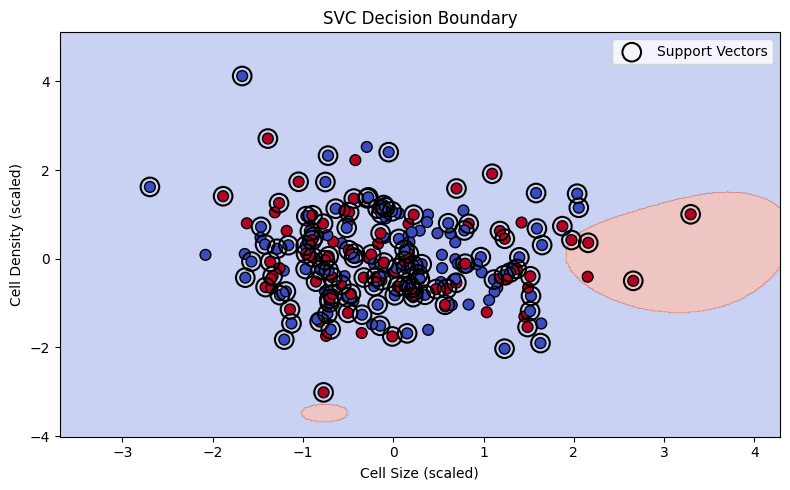

In [1]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

df_medical = pd.read_csv("medical_data.csv")
X = df_medical[['Cell_Size', 'Cell_Density']]
y = df_medical['Malignant']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

clf = SVC(kernel='rbf', C=1.0)
clf.fit(X_train, y_train)

print(f"SVC Accuracy: {accuracy_score(y_test, clf.predict(X_test)) * 100:.2f}%")


print("\nClassification Report:")
print(classification_report(y_test, clf.predict(X_test), target_names=["Benign", "Malignant"]))


def plot_svc_boundary(model, X, y, title="SVC Decision Boundary"):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=60)

    
    plt.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=180, facecolors='none', edgecolors='black',
                linewidths=1.5, label='Support Vectors')

    plt.xlabel("Cell Size (scaled)")
    plt.ylabel("Cell Density (scaled)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_svc_boundary(clf, X_scaled, y)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ..................................C=0.1, kernel=rbf; total time=   0.0s
[CV] END ..................................C=0.1, kernel=rbf; total time=   0.0s
[CV] END ..................................C=0.1, kernel=rbf; total time=   0.0s
[CV] END ..................................C=0.1, kernel=rbf; total time=   0.0s
[CV] END ..................................C=0.1, kernel=rbf; total time=   0.0s
[CV] END .................................C=0.1, kernel=poly; total time=   0.0s
[CV] END .................................C=0.1, kernel=poly; total time=   0.0s
[CV] END .................................C=0.1, kernel=poly; total time=   0.0s
[CV] END .................................C=0.1, kernel=poly; total time=   0.0s
[CV] END .................................C=0.1, kernel=poly; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1,

<Figure size 800x500 with 0 Axes>

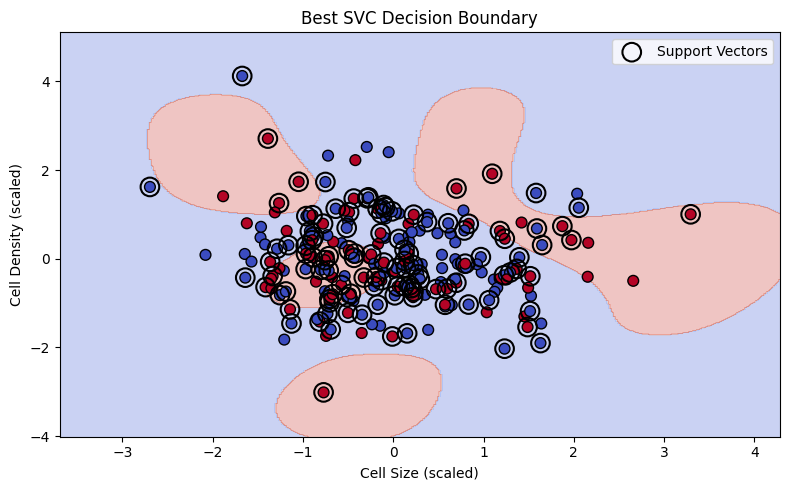

In [2]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'C': [0.1, 1, 10, 100],             # From 'Soft' to 'Hard' margin
    'kernel': ['rbf','poly']                    # Keeping it RBF for now
}

# 2. Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=5)

# 3. Fit the model to find the best combination
grid.fit(X_train, y_train)

# 4. View the results
print(f"\nBest Parameters: {grid.best_params_}")
print(f"Best Cross-Validation Score: {grid.best_score_ * 100:.2f}%")

# 5. Evaluate on the final test set
grid_predictions = grid.predict(X_test)
print(f"Final Test Accuracy: {accuracy_score(y_test, grid_predictions) * 100:.2f}%")

plt.figure(figsize=(8, 5))
plot_svc_boundary(grid.best_estimator_, X_scaled, y, title="Best SVC Decision Boundary")
plt.show()

**SVR**

SVR Mean Absolute Error: $520.33


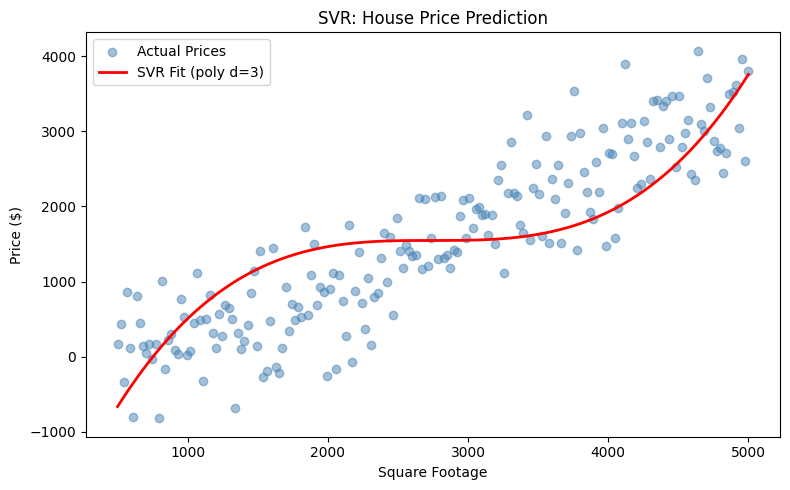

In [4]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

df_houses = pd.read_csv("house_data.csv")
X_reg = df_houses[['SqFt']]
y_reg = df_houses['Price']

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_reg_s = scaler_X.fit_transform(X_reg)
y_reg_s = scaler_y.fit_transform(y_reg.values.reshape(-1, 1)).flatten()


X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg_s, y_reg_s, test_size=0.25, random_state=42
)

regressor = SVR(kernel='poly', degree=3, C=10, epsilon=0.2)
regressor.fit(X_train_r, y_train_r)


preds_s = regressor.predict(X_test_r)
preds_dollars = scaler_y.inverse_transform(preds_s.reshape(-1, 1))
y_test_dollars = scaler_y.inverse_transform(y_test_r.reshape(-1, 1))

print(f"SVR Mean Absolute Error: ${mean_absolute_error(y_test_dollars, preds_dollars):.2f}")

# ── NEW: Visualize SVR fit across the full SqFt range ────────────────────────
X_plot = np.linspace(X_reg_s.min(), X_reg_s.max(), 300).reshape(-1, 1)
y_plot_s = regressor.predict(X_plot)
y_plot_dollars = scaler_y.inverse_transform(y_plot_s.reshape(-1, 1))
X_plot_sqft = scaler_X.inverse_transform(X_plot)

plt.figure(figsize=(8, 5))
plt.scatter(X_reg, y_reg, color='steelblue', alpha=0.5, label='Actual Prices')
plt.plot(X_plot_sqft, y_plot_dollars, color='red', linewidth=2, label='SVR Fit (poly d=3)')
plt.xlabel("Square Footage")
plt.ylabel("Price ($)")
plt.title("SVR: House Price Prediction")
plt.legend()
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END .....................C=0.1, epsilon=0.1, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, epsilon=0.1, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, epsilon=0.1, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, epsilon=0.1, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, epsilon=0.1, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.1, epsilon=0.1, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, epsilon=0.1, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, epsilon=0.1, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, epsilon=0.1, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, epsilon=0.1, kernel=poly; total time=   0.0s
[CV] END .....................C=0.1, epsilon=0.2, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, epsilon=0.

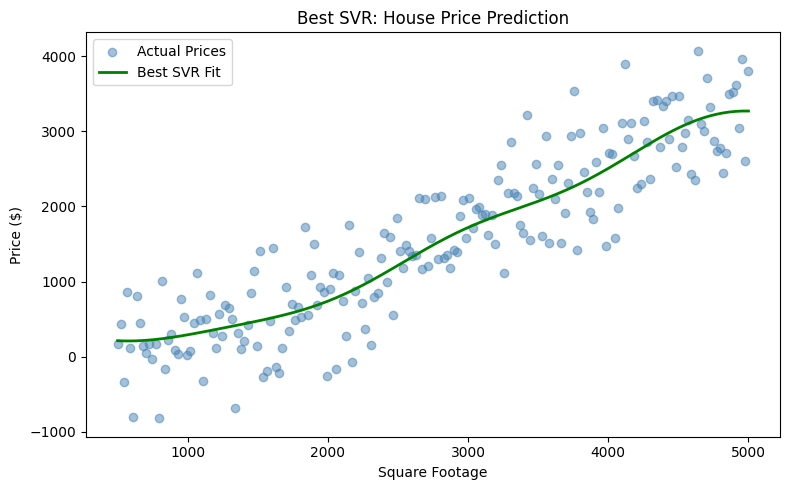

In [5]:
param_grid = {
    'C': [0.1, 1, 10, 100],            # From 'Soft' to 'Hard' margin
    'epsilon': [0.1, 0.2, 0.5, 1.0],   # Size of the tube where errors are ignored
    'kernel': ['rbf','poly']                    # Keeping it RBF for now
}

grid_reg = GridSearchCV(SVR(), param_grid, refit=True, verbose=2, cv=5)
grid_reg.fit(X_reg_s, y_reg_s)
print(f"\nBest Parameters for SVR: {grid_reg.best_params_}")
best_preds_s = grid_reg.predict(X_reg_s)
best_preds_dollars = scaler_y.inverse_transform(best_preds_s.reshape(-1, 1))
print(f"Best SVR Mean Absolute Error: ${mean_absolute_error(y_reg, best_preds_dollars):.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(X_reg, y_reg, color='steelblue', alpha=0.5, label='Actual Prices')
plt.plot(X_plot_sqft, scaler_y.inverse_transform(grid_reg.predict(X_plot).reshape(-1, 1)), color='green', linewidth=2, label='Best SVR Fit')
plt.xlabel("Square Footage")
plt.ylabel("Price ($)")
plt.title("Best SVR: House Price Prediction")
plt.legend()
plt.tight_layout()
plt.show()  


**Decision Tree**

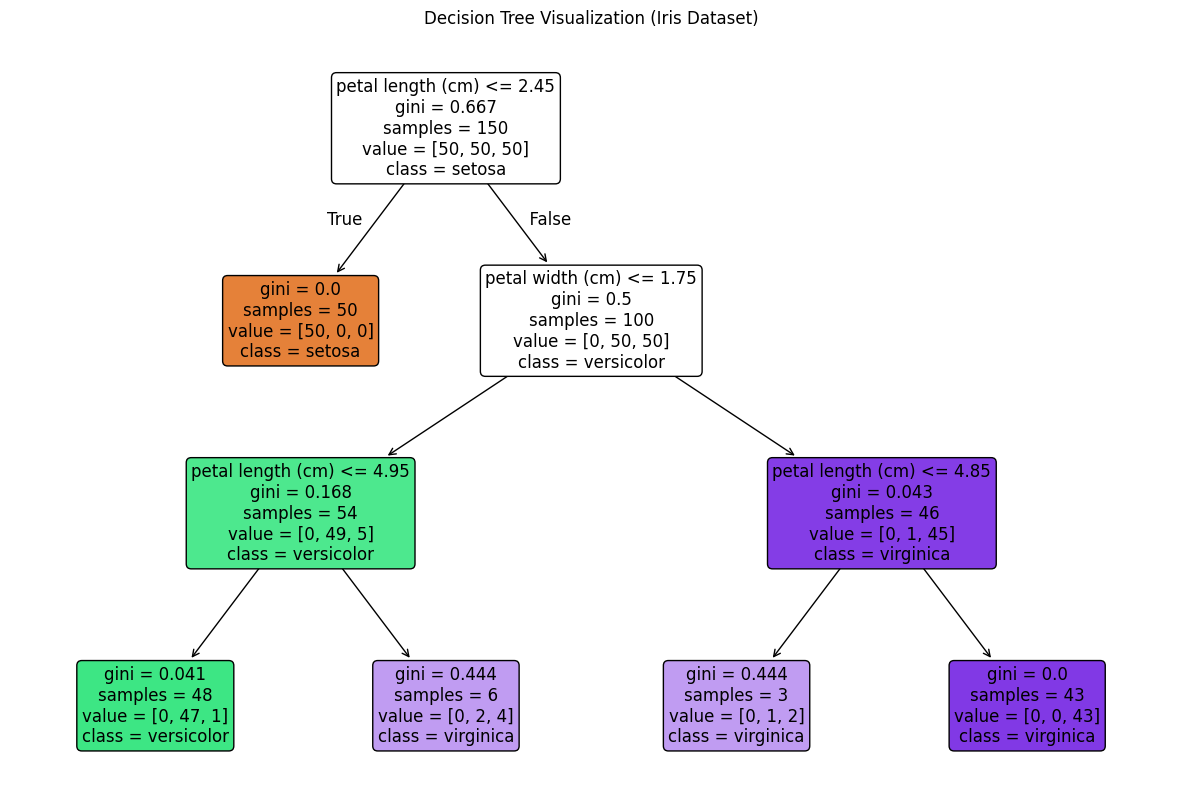

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree


# 1. Load data
iris = load_iris()
X = iris.data
y = iris.target

# 2. Initialize and Train
# We set max_depth=3 so the visualization stays readable
clf = DecisionTreeClassifier(max_depth=3, random_state=42)S
clf.fit(X, y)

# 3. Visualize the Tree
plt.figure(figsize=(15,10))
plot_tree(clf, 
          feature_names=iris.feature_names,  
          class_names=iris.target_names, 
          filled=True, 
          rounded=True,
          fontsize=12)

plt.title("Decision Tree Visualization (Iris Dataset)")
plt.show()

**Random Forest**

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


df_finance = pd.read_csv("credit_data.csv")



X_fin = df_finance.drop('Default', axis=1)
y_fin = df_finance['Default']

X_train, X_test, y_train, y_test = train_test_split(X_fin, y_fin, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42)
rf_model.fit(X_train, y_train)

print("--- Random Forest Finance Report ---")
print(classification_report(y_test, rf_model.predict(X_test)))

--- Random Forest Finance Report ---
              precision    recall  f1-score   support

           0       0.47      0.51      0.49        47
           1       0.53      0.49      0.51        53

    accuracy                           0.50       100
   macro avg       0.50      0.50      0.50       100
weighted avg       0.50      0.50      0.50       100



**Boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score



df_air = pd.read_csv('air_quality_data.csv')



X_air = df_air.drop('AQI', axis=1)
y_air = df_air['AQI']

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_air, y_air, test_size=0.2, random_state=42)


gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_a, y_train_a)

preds = gb_model.predict(X_test_a)
print(f"R2 Score: {r2_score(y_test_a, preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_a, preds)):.2f}")


--- Gradient Boosting Environmental Report ---
R2 Score: 0.9603
RMSE: 5.93


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report

df_air = pd.read_csv("air_quality_data.csv")
X_air = df_air.drop('AQI', axis=1)
y_air = df_air['AQI']

se=StandardScaler()
X_air_scaled = se.fit_transform(X_air)

X_train, X_test, y_train, y_test = train_test_split(X_air_scaled, y_air, test_size=0.2, random_state=42)
log_model = LinearRegression()
log_model.fit(X_train, y_train)
print("--- Linear Regression Environmental Report ---")
print(f"R2 Score: {r2_score(y_test, log_model.predict(X_test)):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, log_model.predict(X_test))):.2f}")



--- Linear Regression Environmental Report ---
R2 Score: 0.9477
RMSE: 6.81
